# Spherical Harmonics — Visual Experiments

> **Goal:** Build intuition for why spherical harmonics are a compact basis for view-dependent color, why degree matters, and why 3D Gaussian Splatting is happy with low-order SH most of the time.

## What we will explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Low-order basis gallery** | What do the first few SH basis functions actually look like on the sphere? |
| 2 | **Degree and storage cost** | Why does expressive power grow with degree, and why does memory grow quadratically? |
| 3 | **Smooth directional color** | How well do low degrees reconstruct a view-dependent signal that changes smoothly with direction? |
| 4 | **Sharp highlight failure mode** | What goes wrong when we ask low-order SH to represent a narrow specular lobe? |
| 5 | **A toy 3DGS Gaussian** | What is the practical difference between a DC-only color term and a full degree-3 SH appearance model? |

---
**Linked theory:** [research/08-spherical-harmonics.md](../research/08-spherical-harmonics.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.30,
})

print('Setup complete.')

Setup complete.


### What you see

1. **What the output shows:** A short confirmation that the plotting environment and numerical tools are ready.
2. **Why it looks this way:** This notebook relies only on `numpy`, `matplotlib`, and SciPy's SH utilities, so the setup is intentionally light and reproducible.
3. **What to take away:** Everything after this point is about the geometry and frequency content of directional functions, not about framework overhead.

---
## A small SH toolkit

The helpers below do four jobs:

1. Build a regular grid of directions on the sphere.
2. Evaluate **real spherical harmonics** on that grid.
3. Fit SH coefficients with least squares.
4. Reconstruct scalar or RGB directional functions from the fitted coefficients.

The point is not to reproduce the exact CUDA renderer used by 3DGS. The point is to make the mathematics transparent enough that each visual has a clean explanation.

In [2]:
ANGLE_EXTENT = [-np.pi, np.pi, -np.pi / 2, np.pi / 2]


def angular_grid(n_az=240, n_el=121):
    az = np.linspace(-np.pi, np.pi, n_az)
    el = np.linspace(-np.pi / 2, np.pi / 2, n_el)
    az_grid, el_grid = np.meshgrid(az, el)
    theta = 0.5 * np.pi - el_grid
    phi = az_grid + np.pi
    return az, el, az_grid, el_grid, theta, phi


def directions_from_angles(theta, phi):
    sin_theta = np.sin(theta)
    x = sin_theta * np.cos(phi)
    y = sin_theta * np.sin(phi)
    z = np.cos(theta)
    return x, y, z


def complex_sh(l, m, theta, phi):
    return sph_harm_y(l, m, theta, phi)


def real_sh(l, m, theta, phi):
    if m > 0:
        return np.sqrt(2.0) * ((-1) ** m) * np.real(complex_sh(l, m, theta, phi))
    if m < 0:
        return np.sqrt(2.0) * ((-1) ** m) * np.imag(complex_sh(l, -m, theta, phi))
    return np.real(complex_sh(l, 0, theta, phi))


def sh_pairs(max_degree):
    return [(l, m) for l in range(max_degree + 1) for m in range(-l, l + 1)]


def design_matrix(max_degree, theta, phi):
    pairs = sh_pairs(max_degree)
    basis = [real_sh(l, m, theta, phi).reshape(-1) for l, m in pairs]
    return np.stack(basis, axis=1), pairs


def fit_sh_scalar(values, max_degree, theta, phi):
    Y, pairs = design_matrix(max_degree, theta, phi)
    coeffs, _, _, _ = np.linalg.lstsq(Y, values.reshape(-1), rcond=None)
    return coeffs, pairs


def fit_sh_rgb(rgb, max_degree, theta, phi):
    Y, pairs = design_matrix(max_degree, theta, phi)
    coeffs = []
    for channel in range(3):
        solution, _, _, _ = np.linalg.lstsq(Y, rgb[..., channel].reshape(-1), rcond=None)
        coeffs.append(solution)
    return np.stack(coeffs, axis=0), pairs


def reconstruct_scalar(coeffs, pairs, theta, phi):
    output = np.zeros_like(theta, dtype=float)
    for weight, (l, m) in zip(coeffs, pairs):
        output += weight * real_sh(l, m, theta, phi)
    return output


def reconstruct_rgb(coeffs, pairs, theta, phi):
    output = np.zeros(theta.shape + (3,), dtype=float)
    for index, (l, m) in enumerate(pairs):
        output += coeffs[:, index][None, None, :] * real_sh(l, m, theta, phi)[..., None]
    return np.clip(output, 0.0, 1.0)


def band_counts(max_degree):
    bands = np.arange(max_degree + 1)
    per_band = 2 * bands + 1
    cumulative = (bands + 1) ** 2
    return bands, per_band, cumulative


def band_energy(coeffs, pairs):
    energy_by_band = {}
    for index, (l, m) in enumerate(pairs):
        energy_by_band.setdefault(l, 0.0)
        energy_by_band[l] += np.linalg.norm(coeffs[:, index]) ** 2
    bands = np.array(sorted(energy_by_band.keys()))
    energies = np.array([energy_by_band[band] for band in bands])
    return bands, energies


def style_angle_axes(ax, title):
    ax.set_title(title)
    ax.set_xlabel('Azimuth (radians)')
    ax.set_ylabel('Elevation (radians)')


def show_rgb_map(ax, rgb, title):
    ax.imshow(np.clip(rgb, 0.0, 1.0), origin='lower', extent=ANGLE_EXTENT, aspect='auto')
    style_angle_axes(ax, title)


print('SH helpers ready.')

SH helpers ready.


### What you see

1. **What the output shows:** Another short confirmation, this time that the helper functions are loaded.
2. **Why it matters:** Every experiment now uses the same pipeline: define a directional function, project it onto SH basis functions, then reconstruct it from a finite degree.
3. **What to take away:** We are measuring the expressive power of SH directly, not hiding it behind a black-box renderer.

---
## Experiment 1: Low-order spherical harmonics are directional patterns

**Question:** What do the first few basis functions actually look like?

A newcomer usually reads the notation \(Y_l^m\) and sees only symbols. The fastest way to build intuition is to look at the basis functions as heatmaps over direction. Positive and negative lobes tell us where a basis function adds or subtracts energy on the sphere.

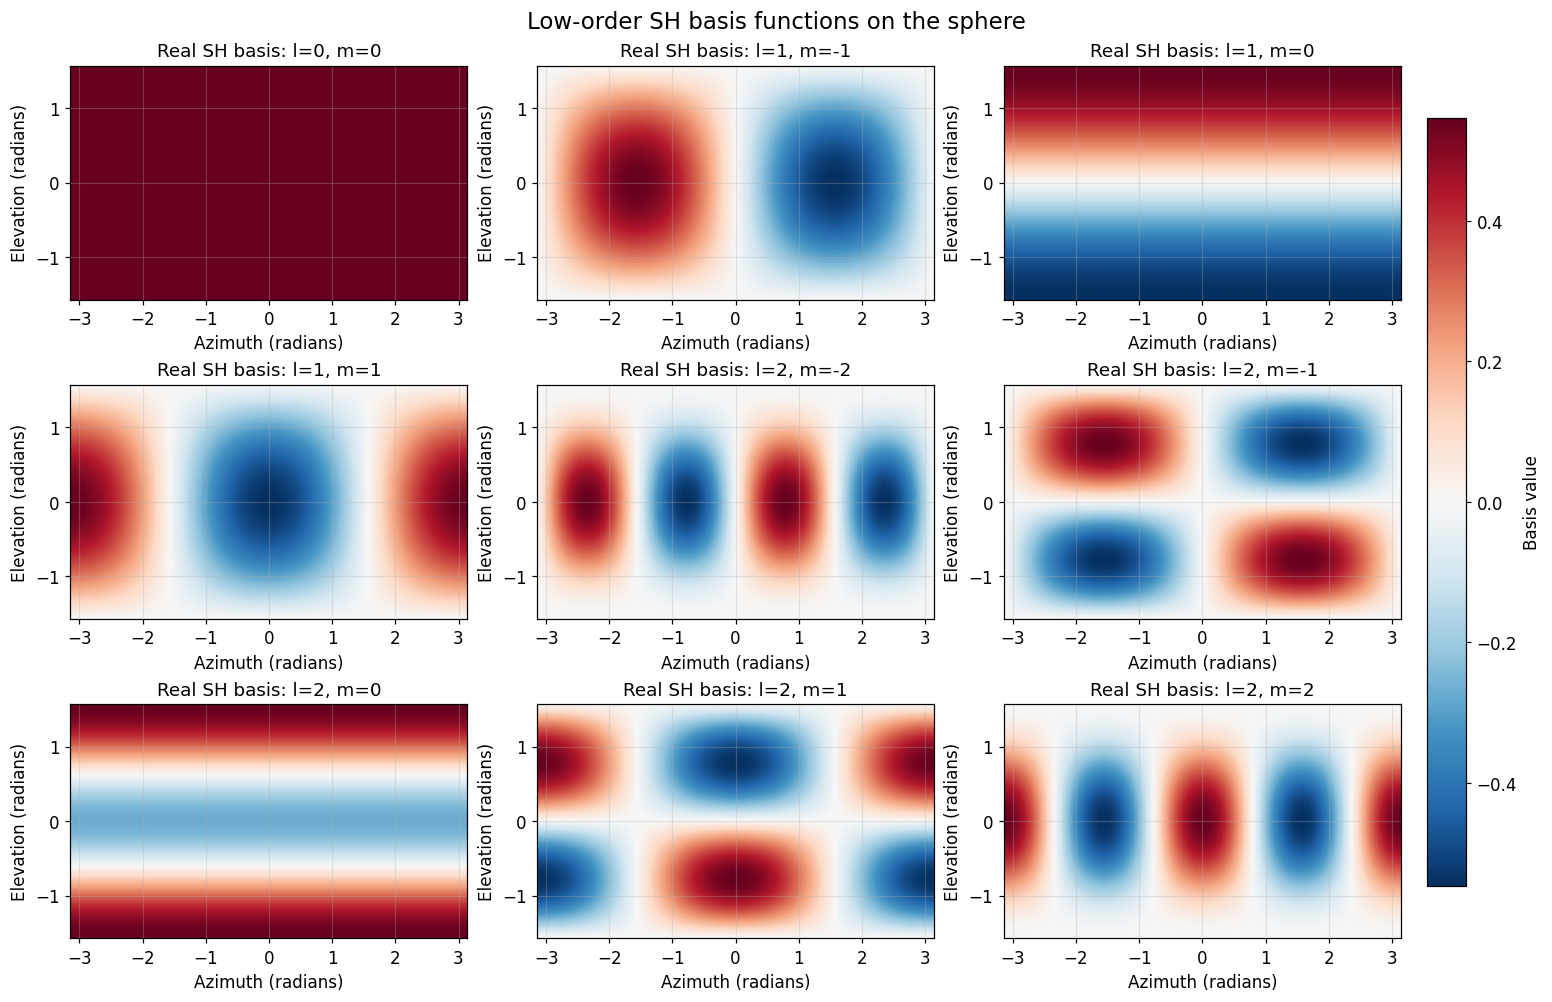

In [3]:
az, el, az_grid, el_grid, theta, phi = angular_grid()
pairs = [(0, 0), (1, -1), (1, 0), (1, 1), (2, -2), (2, -1), (2, 0), (2, 1), (2, 2)]

fig, axes = plt.subplots(3, 3, figsize=(14, 9), constrained_layout=True)
last_image = None
for ax, (l, m) in zip(axes.flat, pairs):
    values = real_sh(l, m, theta, phi)
    vmax = np.max(np.abs(values))
    last_image = ax.imshow(
        values,
        origin='lower',
        extent=ANGLE_EXTENT,
        aspect='auto',
        cmap='RdBu_r',
        vmin=-vmax,
        vmax=vmax,
    )
    style_angle_axes(ax, f'Real SH basis: l={l}, m={m}')

fig.suptitle('Low-order SH basis functions on the sphere', fontsize=15)
cbar = fig.colorbar(last_image, ax=axes, shrink=0.88, pad=0.02)
cbar.set_label('Basis value')
plt.show()

### What you see

1. **What the output shows:** The degree-0 basis is a constant map. Degree-1 basis functions split the sphere into broad positive and negative hemispheres. Degree-2 basis functions already create richer four-lobe and ring-like structures.
2. **Why it looks this way:** Each higher band adds faster angular variation. That is exactly what the `l` index means: larger `l` means more oscillation over direction.
3. **What to take away:** SH is not mysterious. It is simply a family of reusable directional patterns. A directional color function becomes a weighted sum of these patterns.

---
## Experiment 2: Degree buys detail, but it also buys cost

**Question:** Why is `sh_degree = 3` such a common compromise in 3DGS?

The note says the number of basis functions up to degree \(L\) is \((L+1)^2\). That sounds harmless until we plot it. In a 3DGS Gaussian, each extra basis exists for **every RGB channel**, so memory and evaluation cost both grow with degree.

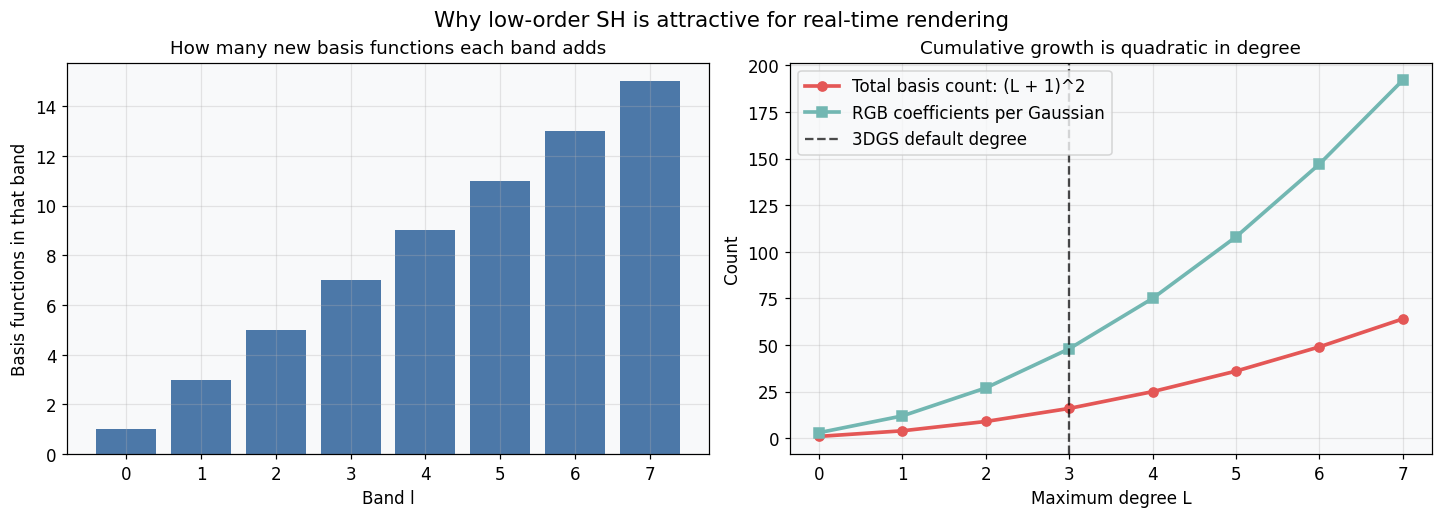

Degree 3 uses 16 basis functions per channel and 48 RGB coefficients per Gaussian.


In [4]:
bands, per_band, cumulative = band_counts(7)
per_gaussian_rgb = 3 * cumulative

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), constrained_layout=True)

axes[0].bar(bands, per_band, color='#4C78A8')
axes[0].set_title('How many new basis functions each band adds')
axes[0].set_xlabel('Band l')
axes[0].set_ylabel('Basis functions in that band')
axes[0].set_xticks(bands)

axes[1].plot(bands, cumulative, marker='o', linewidth=2.4, color='#E45756', label='Total basis count: (L + 1)^2')
axes[1].plot(bands, per_gaussian_rgb, marker='s', linewidth=2.4, color='#72B7B2', label='RGB coefficients per Gaussian')
axes[1].axvline(3, color='black', linestyle='--', alpha=0.7, label='3DGS default degree')
axes[1].set_title('Cumulative growth is quadratic in degree')
axes[1].set_xlabel('Maximum degree L')
axes[1].set_ylabel('Count')
axes[1].set_xticks(bands)
axes[1].legend()

fig.suptitle('Why low-order SH is attractive for real-time rendering', fontsize=14)
plt.show()

print(f'Degree 3 uses {(3 + 1) ** 2} basis functions per channel and {3 * (3 + 1) ** 2} RGB coefficients per Gaussian.')

### What you see

1. **What the output shows:** Each new band adds `2l + 1` basis functions, but the cumulative count follows a quadratic curve. By degree 3, one Gaussian already stores `16` basis functions per channel, or `48` coefficients for RGB.
2. **Why it looks this way:** SH keeps *all* bands from `0` through `L`, so the representation gets denser as detail increases. This is the cost side of the compactness story.
3. **What to take away:** Degree 3 is not magic. It is a practical engineering balance: enough angular detail for smooth view-dependent effects, but still cheap enough to evaluate for many Gaussians.

---
## Experiment 3: Smooth directional color is where low-order SH shines

**Question:** If the true directional signal is smooth, how quickly does SH converge?

We will create a synthetic RGB appearance function whose variation with direction is intentionally smooth. Then we will fit SH expansions with degree `0`, `1`, `2`, and `3` and compare the reconstructions.

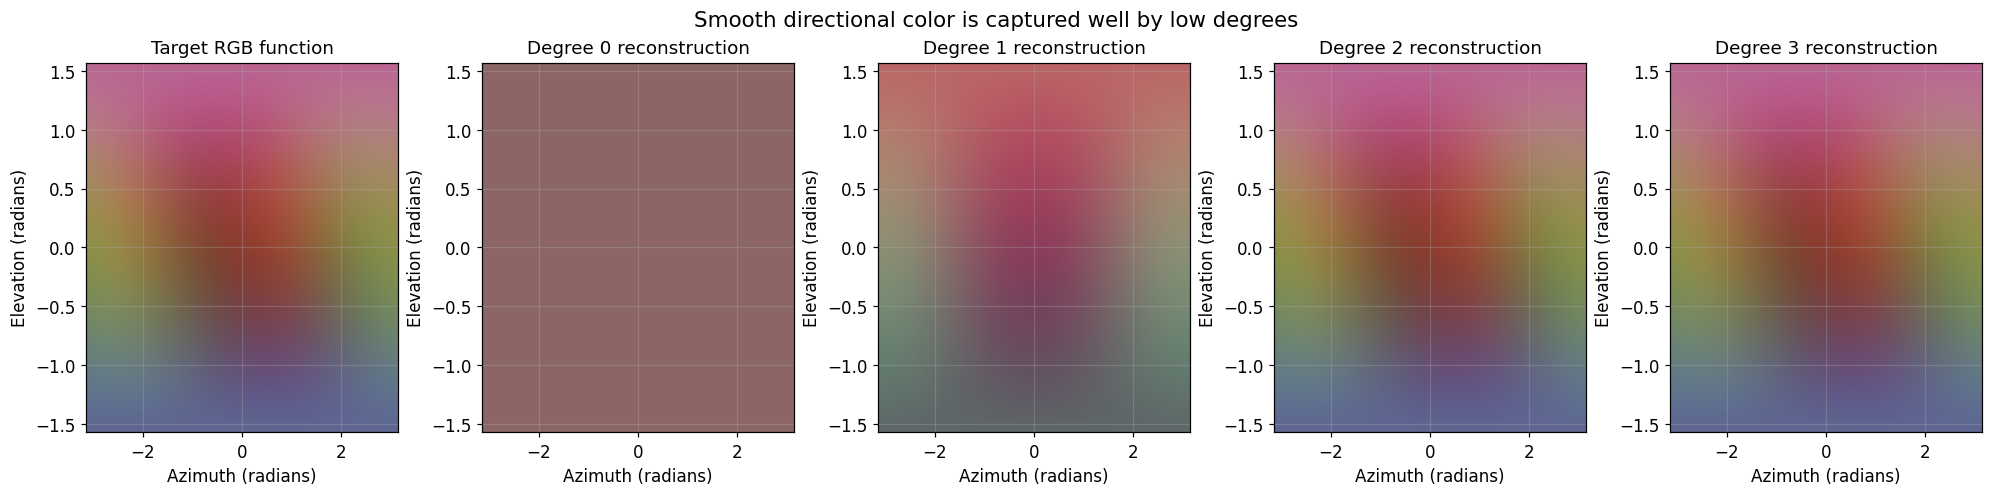

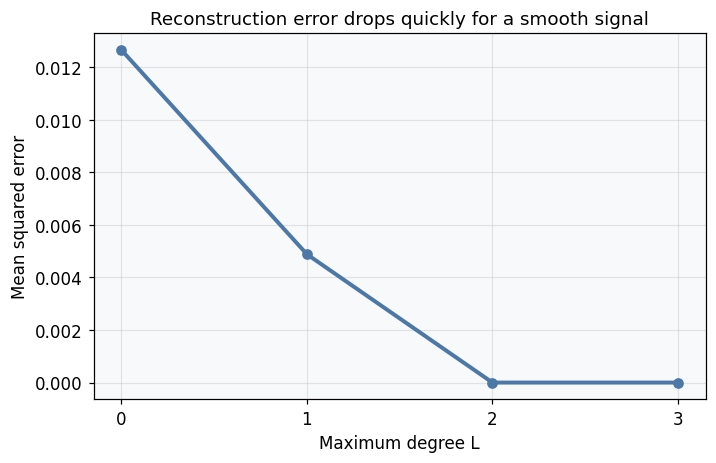

In [5]:
az, el, az_grid, el_grid, theta, phi = angular_grid(220, 111)
x, y, z = directions_from_angles(theta, phi)

smooth_rgb = np.stack([
    0.55 + 0.18 * z + 0.08 * x * y,
    0.40 + 0.16 * x - 0.10 * y * z,
    0.35 + 0.22 * (0.5 * (3 * z ** 2 - 1)) + 0.05 * x,
], axis=-1)
smooth_rgb = np.clip(smooth_rgb, 0.0, 1.0)

degrees = [0, 1, 2, 3]
reconstructions = []
mses = []
for degree in degrees:
    coeffs, pairs = fit_sh_rgb(smooth_rgb, degree, theta, phi)
    reconstructed = reconstruct_rgb(coeffs, pairs, theta, phi)
    reconstructions.append(reconstructed)
    mses.append(np.mean((reconstructed - smooth_rgb) ** 2))

fig, axes = plt.subplots(1, 5, figsize=(18, 4.4), constrained_layout=True)
show_rgb_map(axes[0], smooth_rgb, 'Target RGB function')
for axis, degree, reconstructed in zip(axes[1:], degrees, reconstructions):
    show_rgb_map(axis, reconstructed, f'Degree {degree} reconstruction')
fig.suptitle('Smooth directional color is captured well by low degrees', fontsize=14)
plt.show()

fig, ax = plt.subplots(figsize=(6.4, 4.1), constrained_layout=True)
ax.plot(degrees, mses, marker='o', linewidth=2.6, color='#4C78A8')
ax.set_title('Reconstruction error drops quickly for a smooth signal')
ax.set_xlabel('Maximum degree L')
ax.set_ylabel('Mean squared error')
ax.set_xticks(degrees)
plt.show()

### What you see

1. **What the output shows:** Degree 0 keeps only the average color, so almost all directional structure disappears. Degree 1 restores broad directional trends. By degree 2, the reconstruction is already very close to the target, and degree 3 changes little.
2. **Why it looks this way:** The target was built from smooth, low-frequency directional terms. Those live naturally in the first few SH bands, so the basis matches the signal well.
3. **What to take away:** This is the happy path for SH. When view-dependent color changes smoothly, low-order coefficients are both compact and accurate. That is why SH is a strong fit for many local appearance effects in 3DGS.

---
## Experiment 4: Sharp highlights expose SH's limits

**Question:** What happens when the directional signal is narrow and high-frequency?

Now we replace the smooth RGB function with a scalar intensity lobe that behaves more like a tight specular highlight. This is exactly the kind of signal low-degree SH struggles with.

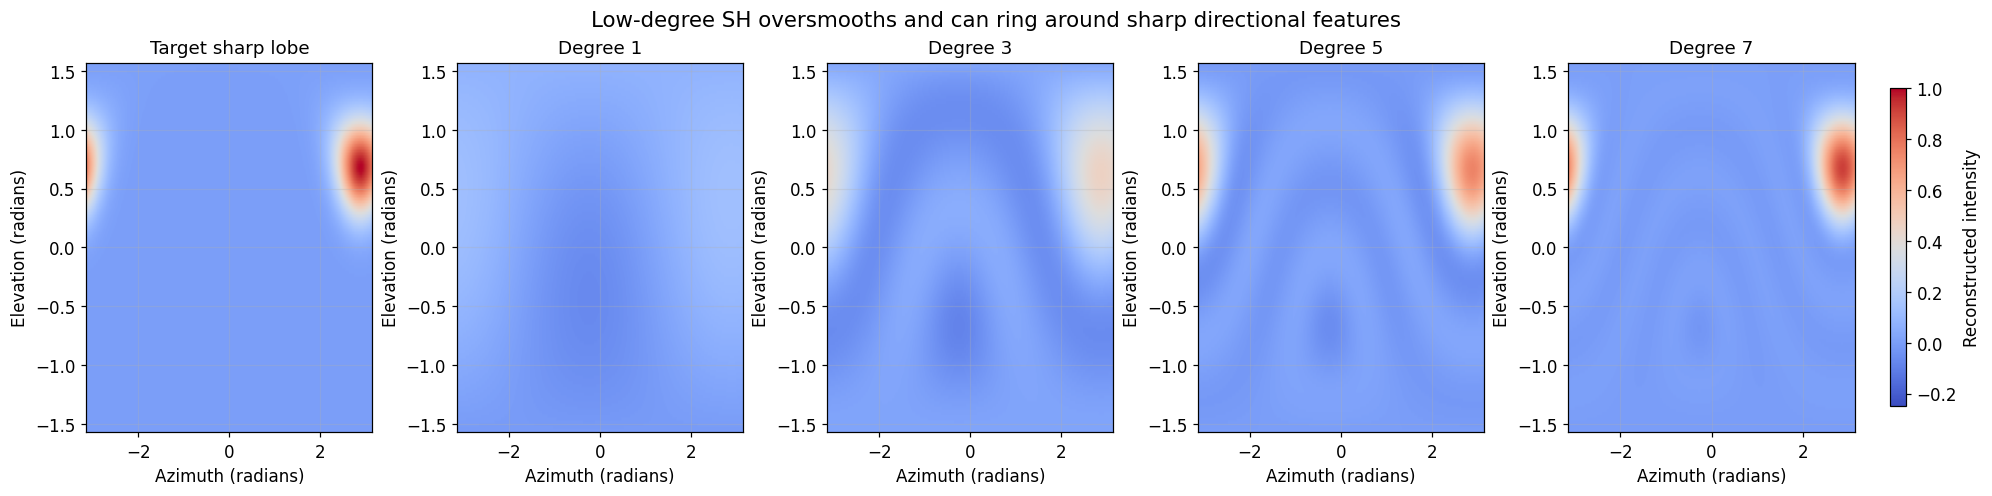

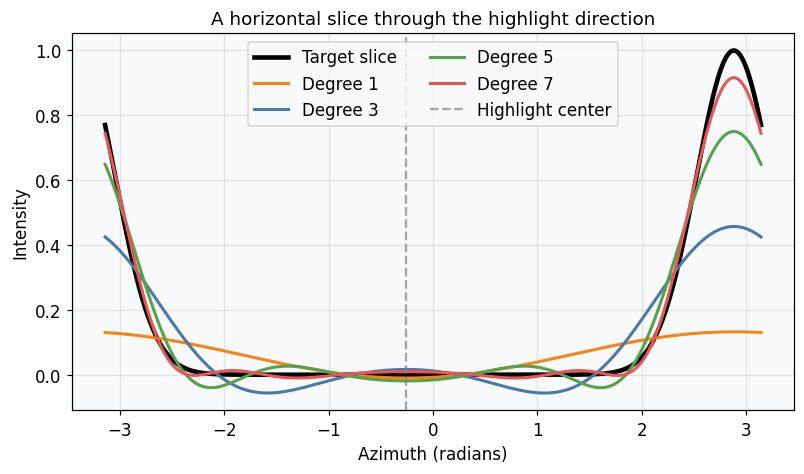

In [6]:
az, el, az_grid, el_grid, theta, phi = angular_grid(260, 131)
x, y, z = directions_from_angles(theta, phi)

highlight_direction = np.array([0.75, -0.20, 0.63], dtype=float)
highlight_direction /= np.linalg.norm(highlight_direction)
dot_product = np.clip(x * highlight_direction[0] + y * highlight_direction[1] + z * highlight_direction[2], -1.0, 1.0)
angle = np.arccos(dot_product)
sigma = 0.28
sharp_lobe = np.exp(-(angle ** 2) / (2 * sigma ** 2))
sharp_lobe = (sharp_lobe - sharp_lobe.min()) / (sharp_lobe.max() - sharp_lobe.min())

sharp_degrees = [1, 3, 5, 7]
sharp_recons = {}
for degree in sharp_degrees:
    coeffs, pairs = fit_sh_scalar(sharp_lobe, degree, theta, phi)
    sharp_recons[degree] = reconstruct_scalar(coeffs, pairs, theta, phi)

fig, axes = plt.subplots(1, 5, figsize=(18, 4.4), constrained_layout=True)
images = [sharp_lobe] + [sharp_recons[degree] for degree in sharp_degrees]
titles = ['Target sharp lobe'] + [f'Degree {degree}' for degree in sharp_degrees]
for ax, image, title in zip(axes, images, titles):
    shown = ax.imshow(
        image,
        origin='lower',
        extent=ANGLE_EXTENT,
        aspect='auto',
        cmap='coolwarm',
        vmin=-0.25,
        vmax=1.0,
    )
    style_angle_axes(ax, title)
fig.colorbar(shown, ax=axes, shrink=0.86, pad=0.02, label='Reconstructed intensity')
fig.suptitle('Low-degree SH oversmooths and can ring around sharp directional features', fontsize=14)
plt.show()

highlight_azimuth = np.arctan2(highlight_direction[1], highlight_direction[0])
highlight_elevation = np.arcsin(highlight_direction[2])
row_index = np.argmin(np.abs(el - highlight_elevation))

fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
ax.plot(az, sharp_lobe[row_index], linewidth=3.0, color='black', label='Target slice')
for degree, color in zip(sharp_degrees, ['#F58518', '#4C78A8', '#54A24B', '#E45756']):
    ax.plot(az, sharp_recons[degree][row_index], linewidth=2.0, color=color, label=f'Degree {degree}')
ax.axvline(highlight_azimuth, color='gray', linestyle='--', alpha=0.7, label='Highlight center')
ax.set_title('A horizontal slice through the highlight direction')
ax.set_xlabel('Azimuth (radians)')
ax.set_ylabel('Intensity')
ax.legend(ncol=2)
plt.show()

### What you see

1. **What the output shows:** Degree 1 and degree 3 produce a broad, blurry approximation of the highlight. Even when the peak is roughly in the right place, the lobe spreads too much and may dip below zero around the sides. Higher degrees improve the fit, but they do so gradually and at a growing cost.
2. **Why it looks this way:** A narrow highlight contains higher angular frequencies than the early SH bands can express. Truncating the expansion forces the basis to approximate a sharp peak with smooth, global functions, which leads to oversmoothing and ringing.
3. **What to take away:** This is the main limitation of SH in 3DGS. Low-order SH is efficient, but it is not the best representation for very sharp specular behavior.

---
## Experiment 5: A toy 3DGS Gaussian with view-dependent RGB

**Question:** What practical difference does degree 3 make compared with a DC-only color term?

In the official 3DGS implementation, the DC term is initialized from `RGB2SH(...)`, and the higher-order coefficients start at zero. That means training begins with a direction-independent color and only later learns view-dependent variation. We can reproduce that idea with a simple toy Gaussian appearance model.

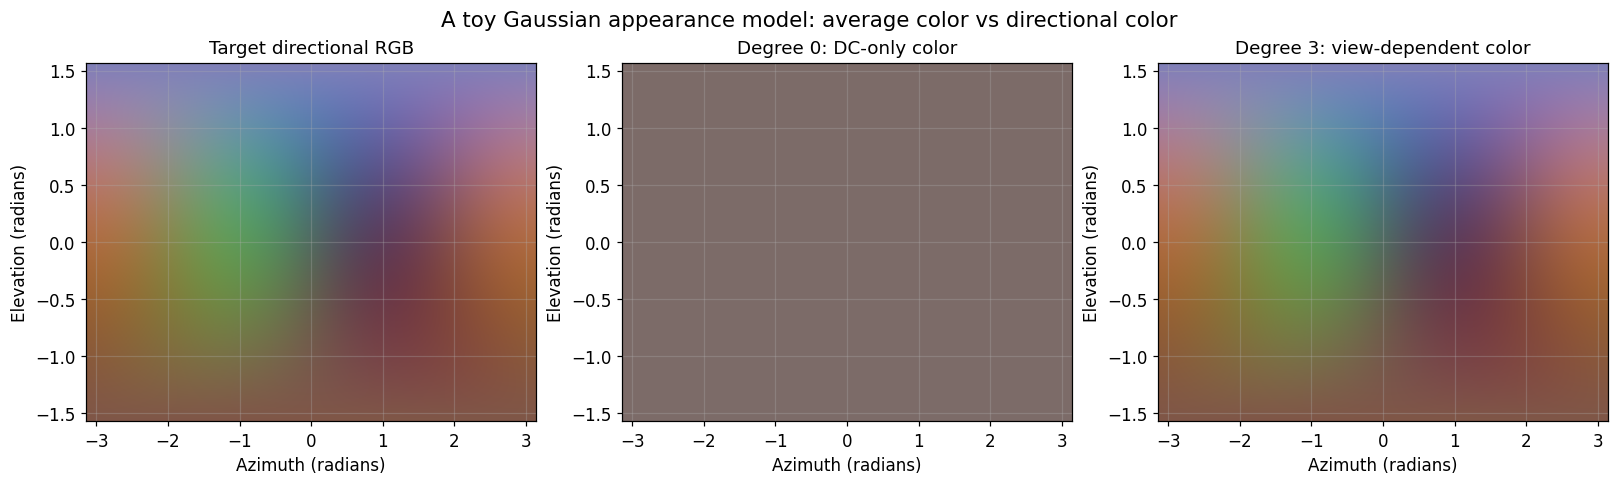

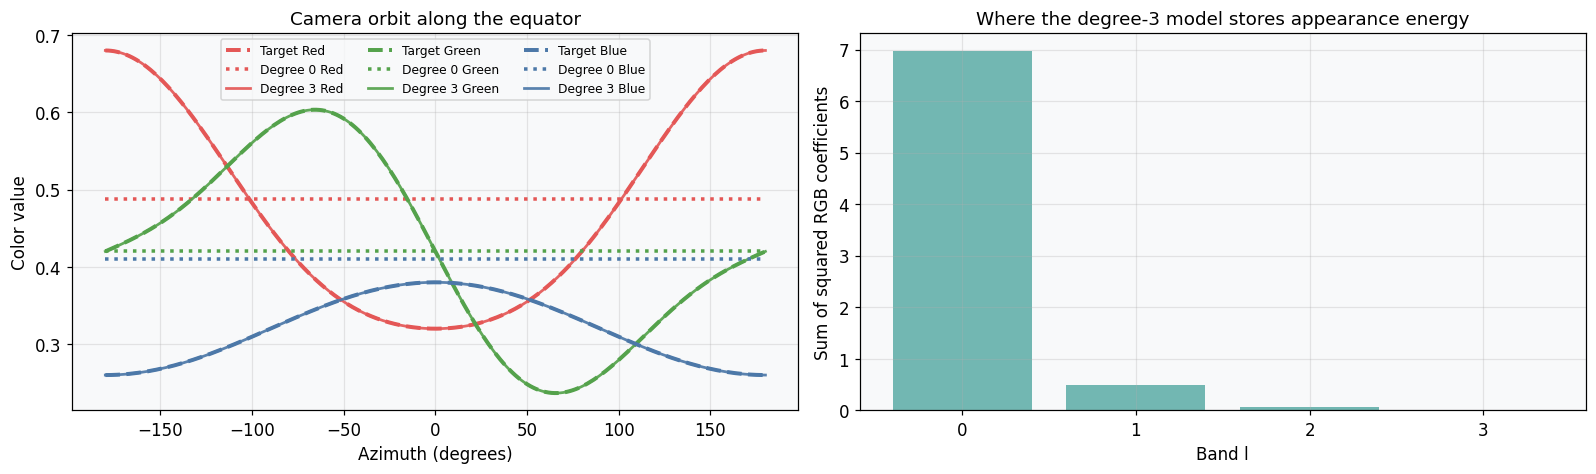

In [7]:
az, el, az_grid, el_grid, theta, phi = angular_grid(220, 111)
x, y, z = directions_from_angles(theta, phi)

toy_rgb = np.stack([
    0.50 + 0.18 * x + 0.12 * x * z - 0.05 * y ** 2,
    0.42 + 0.16 * y - 0.10 * x * y + 0.08 * z,
    0.38 + 0.22 * z + 0.12 * (0.5 * (3 * z ** 2 - 1)) - 0.06 * x,
], axis=-1)
toy_rgb = np.clip(toy_rgb, 0.0, 1.0)

coeffs_deg0, pairs_deg0 = fit_sh_rgb(toy_rgb, 0, theta, phi)
coeffs_deg3, pairs_deg3 = fit_sh_rgb(toy_rgb, 3, theta, phi)

dc_only_rgb = reconstruct_rgb(coeffs_deg0, pairs_deg0, theta, phi)
degree3_rgb = reconstruct_rgb(coeffs_deg3, pairs_deg3, theta, phi)

fig, axes = plt.subplots(1, 3, figsize=(14.6, 4.3), constrained_layout=True)
show_rgb_map(axes[0], toy_rgb, 'Target directional RGB')
show_rgb_map(axes[1], dc_only_rgb, 'Degree 0: DC-only color')
show_rgb_map(axes[2], degree3_rgb, 'Degree 3: view-dependent color')
fig.suptitle('A toy Gaussian appearance model: average color vs directional color', fontsize=14)
plt.show()

equator_row = np.argmin(np.abs(el - 0.0))
channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['#E45756', '#54A24B', '#4C78A8']

fig, axes = plt.subplots(1, 2, figsize=(14.4, 4.2), constrained_layout=True)
for channel, (name, color) in enumerate(zip(channel_names, channel_colors)):
    axes[0].plot(np.rad2deg(az), toy_rgb[equator_row, :, channel], linestyle='--', linewidth=2.6, color=color, label=f'Target {name}')
    axes[0].plot(np.rad2deg(az), dc_only_rgb[equator_row, :, channel], linestyle=':', linewidth=2.3, color=color, label=f'Degree 0 {name}')
    axes[0].plot(np.rad2deg(az), degree3_rgb[equator_row, :, channel], linestyle='-', linewidth=1.8, color=color, alpha=0.92, label=f'Degree 3 {name}')
axes[0].set_title('Camera orbit along the equator')
axes[0].set_xlabel('Azimuth (degrees)')
axes[0].set_ylabel('Color value')
axes[0].legend(ncol=3, fontsize=8)

bands, energies = band_energy(coeffs_deg3, pairs_deg3)
axes[1].bar(bands, energies, color='#72B7B2')
axes[1].set_title('Where the degree-3 model stores appearance energy')
axes[1].set_xlabel('Band l')
axes[1].set_ylabel('Sum of squared RGB coefficients')
axes[1].set_xticks(bands)
plt.show()

### What you see

1. **What the output shows:** The DC-only model keeps just the average color, so the RGB map becomes flat over direction. The degree-3 model recovers directional variation and tracks the target much more closely along a camera orbit.
2. **Why it looks this way:** Degree 0 contains only the constant basis. Degree 3 adds bands that respond to orientation, slope, and smoother higher-order curvature on the sphere. The band-energy plot also shows that the appearance is usually not concentrated in a single coefficient; it spreads across several low-order bands.
3. **What to take away:** In 3DGS, the DC term is a stable starting point, but the higher-order SH coefficients are what let a Gaussian behave like a local radiance primitive instead of a painted point.

---
## Summary / Key Takeaways

- **SH is a directional basis.** The low-order basis gallery makes it concrete: each \(Y_l^m\) is just a reusable directional pattern on the sphere.
- **Degree controls a trade-off.** More bands mean more angular detail, but the number of stored coefficients grows as \((L + 1)^2\).
- **Low-order SH works best for smooth signals.** Smooth directional color converges quickly, which is why low-degree SH is so practical in 3DGS.
- **Sharp specular effects are harder.** Narrow highlights require higher angular frequencies, so truncation causes blur and ringing.
- **For a Gaussian primitive, SH is the appearance half of the story.** Covariance describes geometry, while SH coefficients describe how that primitive changes color with viewing direction.